In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score

In [4]:
columns = [
    "ID", "Diagnosis",
    "radius_mean", "texture_mean", "perimeter_mean", "area_mean",
    "smoothness_mean", "compactness_mean", "concavity_mean",
    "concave_points_mean", "symmetry_mean", "fractal_dimension_mean",
    "radius_se", "texture_se", "perimeter_se", "area_se",
    "smoothness_se", "compactness_se", "concavity_se",
    "concave_points_se", "symmetry_se", "fractal_dimension_se",
    "radius_worst", "texture_worst", "perimeter_worst", "area_worst",
    "smoothness_worst", "compactness_worst", "concavity_worst",
    "concave_points_worst", "symmetry_worst", "fractal_dimension_worst"
]

df = pd.read_csv(
    "/home/mtech1/Downloads/wdbc.data",
    header=None,
    names=columns
)

print(df.shape)
display(df.head())

(569, 32)


,ID,Diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
X = df.drop(columns=["ID", "Diagnosis"])
y = df["Diagnosis"].map({"M": 1, "B": 0})

print("X Shape:", X.shape)
print("y Shape:", y.shape)
print(y.value_counts())

X Shape: (569, 30)
y Shape: (569,)
Diagnosis
0    357
1    212
Name: count, dtype: int64


# Dataset Inspection

Check the structure, data types, missing values, duplicate records, and statistical properties of the dataset.

In [6]:
print(df.info())

print("\nMissing Values:")
print(X.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

display(X.describe().T)

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       569 non-null    int64  
 1   Diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             569 non-null

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### Observation

The dataset consists of numerical predictor variables and a binary target. The missing-value count and duplicate count are checked before model training.

# Exploratory Data Analysis – Class Distribution

Visualize the distribution of malignant and benign cases in the dataset.

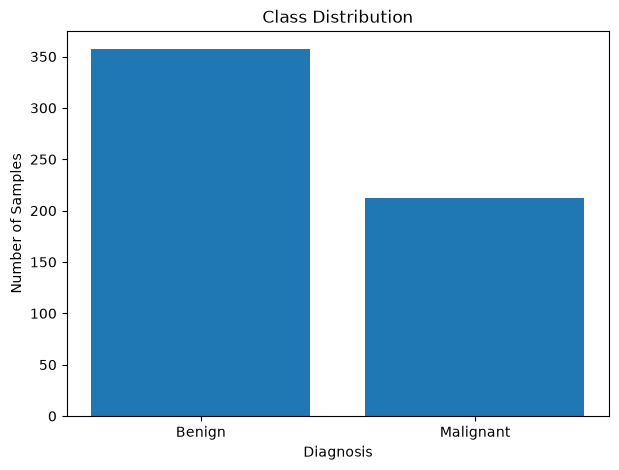

In [13]:
class_counts = df["Diagnosis"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(
    ["Benign", "Malignant"],
    [class_counts["B"], class_counts["M"]]
)
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")
plt.show()

### Observation

The dataset contains both benign and malignant cases, with benign cases occurring more frequently than malignant cases.

# Exploratory Data Analysis – Feature Correlation

Analyze the relationships among the numerical features using a correlation heatmap.

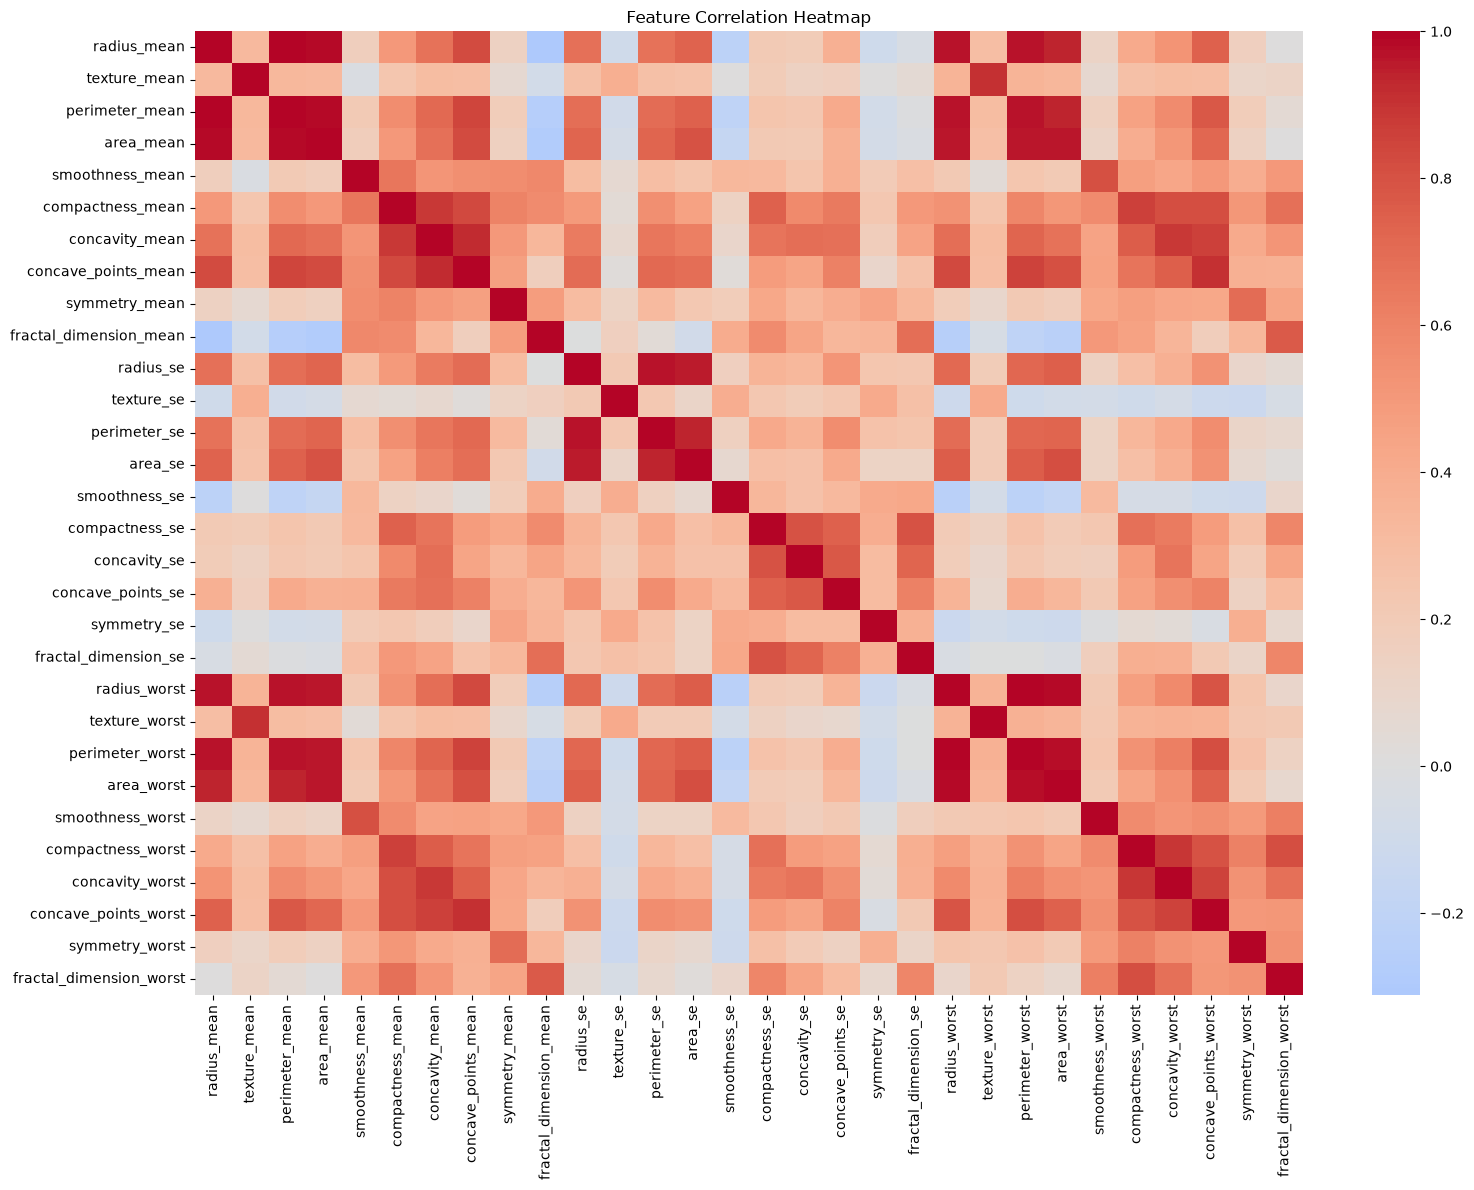

In [18]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    X.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

### Observation

Several features show strong correlations with one another, indicating that some measurements contain related information.

# Train-Test Split

Split the dataset into training and testing sets using an 80–20 ratio while preserving the class distribution.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (455, 30)
X_test : (114, 30)
y_train: (455,)
y_test : (114,)


### Observation

The dataset has been divided into 80% training data and 20% testing data using stratified sampling.

# Feature Scaling

Standardize the numerical features so that models such as SVM and Logistic Regression are not affected by differences in feature scales.

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Observation

The training features were standardized using the training data, and the same transformation was applied to the testing data.

# Bagging Classifier

Implement a Bagging classifier using Decision Trees as the base estimator. Bagging trains multiple models on bootstrap samples and combines their predictions.

In [22]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42
)

start_time = time.time()

bagging_model.fit(X_train, y_train)

bagging_training_time = time.time() - start_time

y_pred_bagging = bagging_model.predict(X_test)

### Observation

The Bagging classifier was trained using multiple Decision Trees. Combining the predictions of multiple trees helps reduce variance and improve model stability.

# Bagging Performance Evaluation

Evaluate the Bagging classifier using Accuracy, Precision, Recall, and F1-score.

In [23]:
bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(y_test, y_pred_bagging)
bagging_recall = recall_score(y_test, y_pred_bagging)
bagging_f1 = f1_score(y_test, y_pred_bagging)

print("Accuracy :", round(bagging_accuracy, 4))
print("Precision:", round(bagging_precision, 4))
print("Recall   :", round(bagging_recall, 4))
print("F1 Score :", round(bagging_f1, 4))
print("Training Time:", round(bagging_training_time, 4))

Accuracy : 0.9737
Precision: 1.0
Recall   : 0.9286
F1 Score : 0.963
Training Time: 0.267


### Observation

The Bagging classifier performance is measured using the standard classification metrics. These results provide a baseline for comparison with the boosting and stacking models.

# Bagging Hyperparameter Tuning

Evaluate different values of the number of estimators, number of samples, and number of features using Grid Search with 5-Fold Cross-Validation.

In [24]:
bagging_params = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

bagging_grid = GridSearchCV(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),
    bagging_params,
    cv=cv,
    scoring=["accuracy", "f1"],
    refit="f1",
    return_train_score=True,
    n_jobs=-1
)

bagging_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassi...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_features': [0.5, 0.8, ...], 'max_samples': [0.5, 0.8, ...], 'n_estimators': [10, 50, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuf

### Observation

Grid Search evaluates different Bagging configurations using 5-Fold Cross-Validation and selects the configuration with the best F1-score.

# Bagging Hyperparameter Evaluation

Display the average cross-validation Accuracy and F1-score for the different Bagging hyperparameter combinations.

In [25]:
bagging_results = pd.DataFrame(bagging_grid.cv_results_)

bagging_table = bagging_results[
    [
        "param_n_estimators",
        "param_max_samples",
        "param_max_features",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

bagging_table.columns = [
    "N Estimators",
    "Max Samples",
    "Max Features",
    "Avg CV Accuracy",
    "Avg CV F1 Score"
]

bagging_table = bagging_table.sort_values(
    "Avg CV F1 Score",
    ascending=False
)

display(bagging_table)

,N Estimators,Max Samples,Max Features,Avg CV Accuracy,Avg CV F1 Score
7,50,1.0,0.5,0.969231,0.958273
4,50,0.8,0.5,0.967033,0.955381
8,100,1.0,0.5,0.967033,0.955097
22,50,0.8,1.0,0.964835,0.952577
14,100,0.8,0.8,0.964835,0.952212
13,50,0.8,0.8,0.964835,0.952212
11,100,0.5,0.8,0.964835,0.952105
1,50,0.5,0.5,0.964835,0.951740
26,100,1.0,1.0,0.962637,0.949562
12,10,0.8,0.8,0.962637,0.948952


Exception ignored in: <function ResourceTracker.__del__ at 0x7cc10c5885e0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x74dda7e845e0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7625487905e0>
Traceback (most recent 

### Observation

The hyperparameter results show how the number of estimators, sample size, and feature sampling affect the cross-validation performance of Bagging.

# Best Bagging Model

Train the Bagging classifier using the best hyperparameters obtained through Grid Search.

In [26]:
best_bagging = bagging_grid.best_estimator_

start_time = time.time()

best_bagging.fit(X_train, y_train)

bagging_training_time = time.time() - start_time

y_pred_bagging = best_bagging.predict(X_test)

bagging_accuracy = accuracy_score(y_test, y_pred_bagging)
bagging_precision = precision_score(y_test, y_pred_bagging)
bagging_recall = recall_score(y_test, y_pred_bagging)
bagging_f1 = f1_score(y_test, y_pred_bagging)

print("Best Parameters:")
print(bagging_grid.best_params_)

print("\nAccuracy:", round(bagging_accuracy, 4))
print("Precision:", round(bagging_precision, 4))
print("Recall:", round(bagging_recall, 4))
print("F1 Score:", round(bagging_f1, 4))

Best Parameters:
{'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 50}

Accuracy: 0.9649
Precision: 1.0
Recall: 0.9048
F1 Score: 0.95


### Observation

The best Bagging configuration obtained through 5-Fold Cross-Validation was used to train the final Bagging model and evaluate its test performance.

# AdaBoost Classifier

Implement AdaBoost using Decision Trees as weak learners. Each subsequent learner focuses more on samples that were incorrectly classified by previous learners.

In [27]:
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(
        max_depth=1,
        random_state=42
    ),
    n_estimators=100,
    learning_rate=0.5,
    random_state=42
)

start_time = time.time()

adaboost_model.fit(X_train, y_train)

adaboost_training_time = time.time() - start_time

y_pred_adaboost = adaboost_model.predict(X_test)

### Observation

AdaBoost trains weak learners sequentially and gives greater importance to samples that were previously misclassified.

# AdaBoost Performance Evaluation

Evaluate the AdaBoost classifier using Accuracy, Precision, Recall, and F1-score.

In [28]:
adaboost_accuracy = accuracy_score(y_test, y_pred_adaboost)
adaboost_precision = precision_score(y_test, y_pred_adaboost)
adaboost_recall = recall_score(y_test, y_pred_adaboost)
adaboost_f1 = f1_score(y_test, y_pred_adaboost)

print("Accuracy :", round(adaboost_accuracy, 4))
print("Precision:", round(adaboost_precision, 4))
print("Recall   :", round(adaboost_recall, 4))
print("F1 Score :", round(adaboost_f1, 4))
print("Training Time:", round(adaboost_training_time, 4))

Accuracy : 0.9737
Precision: 1.0
Recall   : 0.9286
F1 Score : 0.963
Training Time: 0.1411


### Observation

The AdaBoost classifier provides its classification performance after sequentially combining multiple weak learners.

# AdaBoost Hyperparameter Tuning

Evaluate different numbers of estimators, learning rates, and Decision Tree depths using 5-Fold Cross-Validation.

In [29]:
adaboost_params = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 0.5, 1.0],
    "estimator__max_depth": [1, 2, 3]
}

adaboost_grid = GridSearchCV(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),
    adaboost_params,
    cv=cv,
    scoring=["accuracy", "f1"],
    refit="f1",
    return_train_score=True,
    n_jobs=-1
)

adaboost_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostClass...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator__max_depth': [1, 2, ...], 'learning_rate': [0.01, 0.1, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'f1']"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'f1'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo

### Observation

Different AdaBoost configurations were evaluated using 5-Fold Cross-Validation. The best configuration is selected according to the F1-score.

# AdaBoost Hyperparameter Evaluation

Display the average cross-validation Accuracy and F1-score for the different AdaBoost configurations.

In [30]:
adaboost_results = pd.DataFrame(adaboost_grid.cv_results_)

adaboost_table = adaboost_results[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_estimator__max_depth",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
].copy()

adaboost_table.columns = [
    "N Estimators",
    "Learning Rate",
    "Max Depth",
    "Avg CV Accuracy",
    "Avg CV F1 Score"
]

adaboost_table = adaboost_table.sort_values(
    "Avg CV F1 Score",
    ascending=False
)

display(adaboost_table.head(15))

,N Estimators,Learning Rate,Max Depth,Avg CV Accuracy,Avg CV F1 Score
23,150,1.0,2,0.975824,0.967235
8,150,0.5,1,0.973626,0.964332
34,100,1.0,3,0.973626,0.964264
21,50,1.0,2,0.973626,0.964255
11,150,1.0,1,0.971429,0.961442
30,50,0.5,3,0.971429,0.961273
33,50,1.0,3,0.971429,0.960992
22,100,1.0,2,0.971429,0.960982
20,150,0.5,2,0.971429,0.960979
17,150,0.1,2,0.971429,0.960805


### Observation

The results show how the number of estimators, learning rate, and tree depth influence AdaBoost performance.

# Best AdaBoost Model

Train and evaluate AdaBoost using the best hyperparameters obtained from Grid Search.

In [31]:
best_adaboost = adaboost_grid.best_estimator_

start_time = time.time()

best_adaboost.fit(X_train, y_train)

adaboost_training_time = time.time() - start_time

y_pred_adaboost = best_adaboost.predict(X_test)

adaboost_accuracy = accuracy_score(y_test, y_pred_adaboost)
adaboost_precision = precision_score(y_test, y_pred_adaboost)
adaboost_recall = recall_score(y_test, y_pred_adaboost)
adaboost_f1 = f1_score(y_test, y_pred_adaboost)

print("Best Parameters:")
print(adaboost_grid.best_params_)

print("\nAccuracy:", round(adaboost_accuracy, 4))
print("Precision:", round(adaboost_precision, 4))
print("Recall:", round(adaboost_recall, 4))
print("F1 Score:", round(adaboost_f1, 4))

Best Parameters:
{'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 150}

Accuracy: 0.9737
Precision: 1.0
Recall: 0.9286
F1 Score: 0.963


### Observation

The tuned AdaBoost model was trained using the best hyperparameters and evaluated on the unseen test data.

# Gradient Boosting Classifier

Implement Gradient Boosting as another boosting method in which models are trained sequentially to reduce prediction errors.

In [32]:
gradient_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

start_time = time.time()

gradient_model.fit(X_train, y_train)

gradient_training_time = time.time() - start_time

y_pred_gradient = gradient_model.predict(X_test)

### Observation

Gradient Boosting sequentially builds decision trees to improve the predictions made by the previous trees.

# Gradient Boosting Performance Evaluation

Evaluate the Gradient Boosting classifier using Accuracy, Precision, Recall, and F1-score.

In [33]:
gradient_accuracy = accuracy_score(y_test, y_pred_gradient)
gradient_precision = precision_score(y_test, y_pred_gradient)
gradient_recall = recall_score(y_test, y_pred_gradient)
gradient_f1 = f1_score(y_test, y_pred_gradient)

print("Accuracy :", round(gradient_accuracy, 4))
print("Precision:", round(gradient_precision, 4))
print("Recall   :", round(gradient_recall, 4))
print("F1 Score :", round(gradient_f1, 4))
print("Training Time:", round(gradient_training_time, 4))

Accuracy : 0.9649
Precision: 1.0
Recall   : 0.9048
F1 Score : 0.95
Training Time: 0.1992


### Observation

Gradient Boosting provides another boosting-based ensemble for comparison with Bagging and AdaBoost.

# Stacked Ensemble

Construct a Stacked Ensemble using SVM, Naive Bayes, and Decision Tree as base learners and Logistic Regression as the meta-learner.

In [34]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(probability=True, random_state=42))
])

nb_model = GaussianNB()

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

stacked_model = StackingClassifier(
    estimators=[
        ("svm", svm_model),
        ("naive_bayes", nb_model),
        ("decision_tree", dt_model)
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

start_time = time.time()

stacked_model.fit(X_train, y_train)

stacking_training_time = time.time() - start_time

y_pred_stacking = stacked_model.predict(X_test)

/home/mtech1/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mtech1/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mtech1/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mtech1/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be remov

### Observation

The Stacked Ensemble combines predictions from SVM, Naive Bayes, and Decision Tree and uses Logistic Regression as the meta-learner to produce the final prediction.

# Stacked Ensemble Performance Evaluation

Evaluate the Stacked Ensemble using Accuracy, Precision, Recall, and F1-score.

In [35]:
stacking_accuracy = accuracy_score(y_test, y_pred_stacking)
stacking_precision = precision_score(y_test, y_pred_stacking)
stacking_recall = recall_score(y_test, y_pred_stacking)
stacking_f1 = f1_score(y_test, y_pred_stacking)

print("Accuracy :", round(stacking_accuracy, 4))
print("Precision:", round(stacking_precision, 4))
print("Recall   :", round(stacking_recall, 4))
print("F1 Score :", round(stacking_f1, 4))
print("Training Time:", round(stacking_training_time, 4))

Accuracy : 0.9649
Precision: 1.0
Recall   : 0.9048
F1 Score : 0.95
Training Time: 0.112


### Observation

The Stacked Ensemble combines heterogeneous base models and evaluates their combined predictive performance.

# 5-Fold Cross-Validation Performance Comparison

Compare the cross-validation accuracy and F1-score of Bagging, AdaBoost, Gradient Boosting, and Stacked Ensemble models.

In [ ]:
models = {
    "Bagging": best_bagging,
    "AdaBoost": best_adaboost,
    "Gradient Boosting": gradient_model,
    "Stacked Ensemble": stacked_model
}

cv_results = []

for name, model in models.items():
    accuracy_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    f1_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="f1",
        n_jobs=-1
    )

    cv_results.append([
        name,
        accuracy_scores.mean(),
        f1_scores.mean()
    ])

cv_table = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Avg CV Accuracy",
        "Avg CV F1 Score"
    ]
)

display(cv_table.round(4))

### Observation

The 5-Fold Cross-Validation results provide a stable comparison of the ensemble models across different training and validation partitions.

# Performance Comparison of Ensemble Models

Compare Bagging, AdaBoost, Gradient Boosting, and Stacked Ensemble using Accuracy, Precision, Recall, and F1-score.

In [37]:
performance_table = pd.DataFrame({
    "Model": [
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "Stacked Ensemble"
    ],
    "Accuracy": [
        bagging_accuracy,
        adaboost_accuracy,
        gradient_accuracy,
        stacking_accuracy
    ],
    "Precision": [
        bagging_precision,
        adaboost_precision,
        gradient_precision,
        stacking_precision
    ],
    "Recall": [
        bagging_recall,
        adaboost_recall,
        gradient_recall,
        stacking_recall
    ],
    "F1 Score": [
        bagging_f1,
        adaboost_f1,
        gradient_f1,
        stacking_f1
    ]
})

display(performance_table.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Bagging,0.9649,1.0,0.9048,0.950
1,AdaBoost,0.9737,1.0,0.9286,0.963
2,Gradient Boosting,0.9649,1.0,0.9048,0.950
3,Stacked Ensemble,0.9649,1.0,0.9048,0.950


### Observation

The performance table allows direct comparison of the predictive performance of the different ensemble learning strategies.

# Confusion Matrix Comparison

Visualize the confusion matrices of all ensemble models to examine their correct and incorrect classifications.

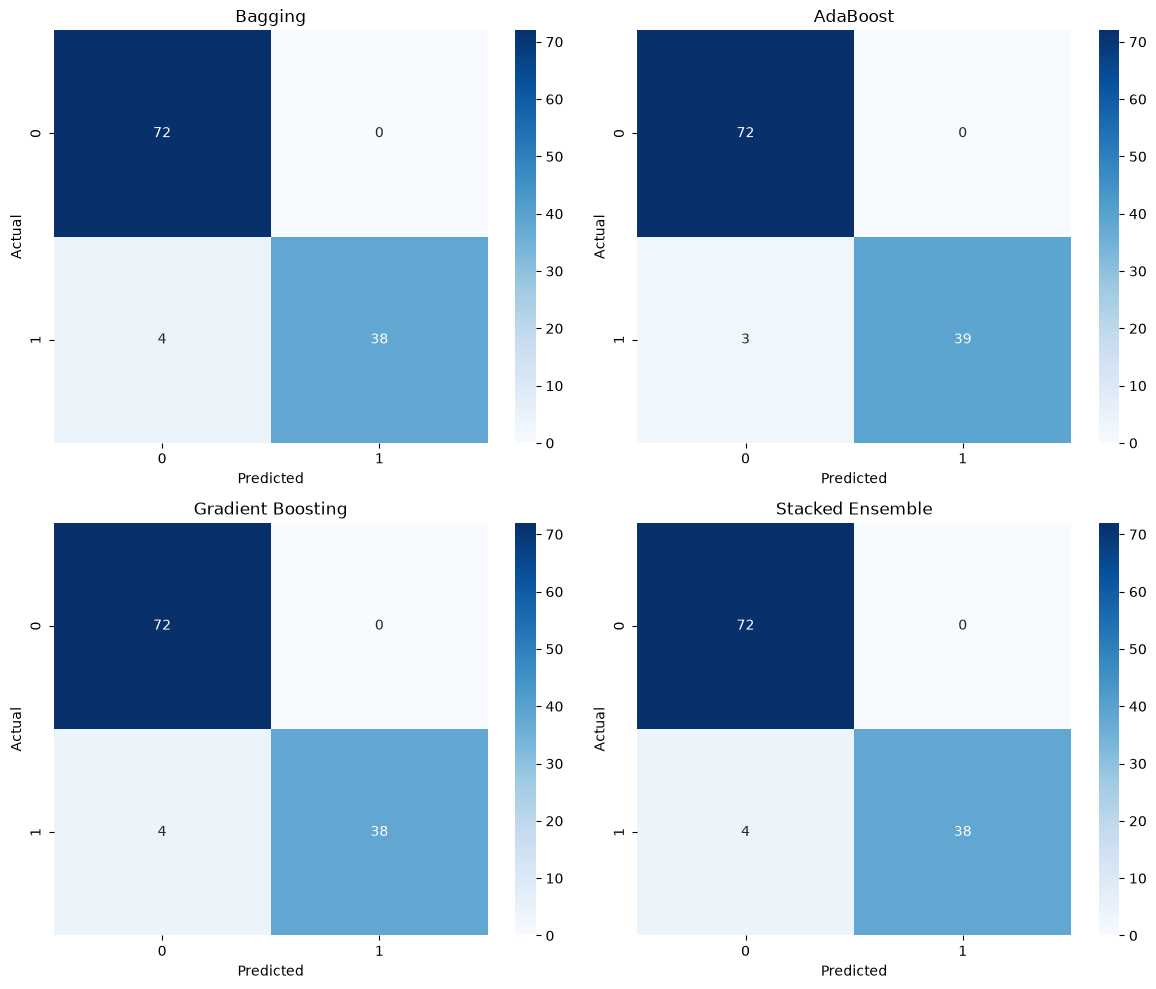

In [38]:
predictions = {
    "Bagging": y_pred_bagging,
    "AdaBoost": y_pred_adaboost,
    "Gradient Boosting": y_pred_gradient,
    "Stacked Ensemble": y_pred_stacking
}

plt.figure(figsize=(12, 10))

for i, (name, predictions_model) in enumerate(predictions.items(), 1):
    plt.subplot(2, 2, i)

    cm = confusion_matrix(y_test, predictions_model)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

### Observation

The confusion matrices show the numbers of correctly and incorrectly classified benign and malignant cases for each ensemble model.

# ROC Curve and AUC Comparison

Compare the ensemble models using ROC curves and Area Under the Curve values.

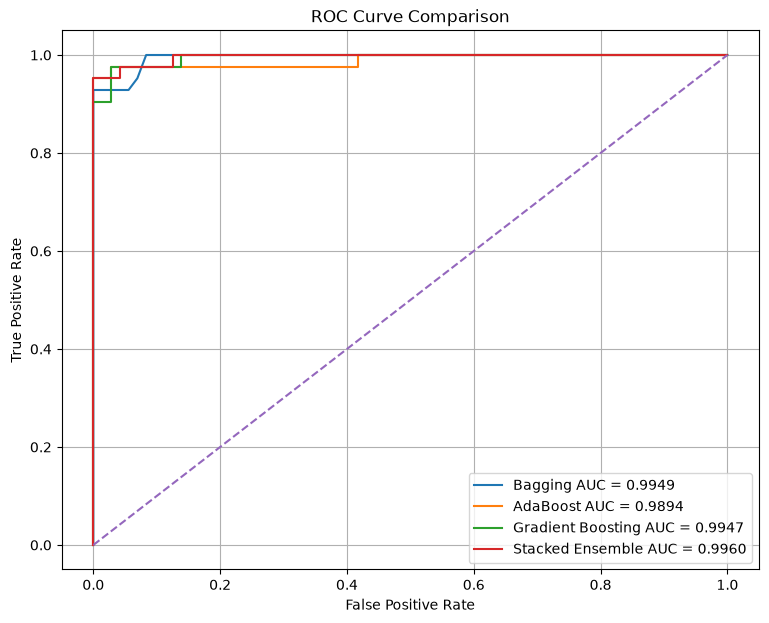

Bagging AUC: 0.9949
AdaBoost AUC: 0.9894
Gradient Boosting AUC: 0.9947
Stacked Ensemble AUC: 0.996


In [39]:
probabilities = {
    "Bagging": best_bagging.predict_proba(X_test)[:, 1],
    "AdaBoost": best_adaboost.predict_proba(X_test)[:, 1],
    "Gradient Boosting": gradient_model.predict_proba(X_test)[:, 1],
    "Stacked Ensemble": stacked_model.predict_proba(X_test)[:, 1]
}

auc_results = {}

plt.figure(figsize=(9, 7))

for name, probability in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probability)
    auc_value = roc_auc_score(y_test, probability)

    auc_results[name] = auc_value

    plt.plot(
        fpr,
        tpr,
        label=f"{name} AUC = {auc_value:.4f}"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

for name, value in auc_results.items():
    print(name, "AUC:", round(value, 4))

### Observation

The ROC curves compare the ability of the ensemble models to distinguish between benign and malignant cases. A higher AUC indicates better classification ability across different thresholds.

# Final Ensemble Model Comparison

Combine the standard classification metrics and AUC values into a final comparison table.

In [40]:
final_table = performance_table.copy()

final_table["AUC"] = [
    auc_results["Bagging"],
    auc_results["AdaBoost"],
    auc_results["Gradient Boosting"],
    auc_results["Stacked Ensemble"]
]

display(final_table.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Bagging,0.9649,1.0,0.9048,0.950,0.9949
1,AdaBoost,0.9737,1.0,0.9286,0.963,0.9894
2,Gradient Boosting,0.9649,1.0,0.9048,0.950,0.9947
3,Stacked Ensemble,0.9649,1.0,0.9048,0.950,0.9960


### Observation

The final comparison summarizes the overall performance of Bagging, Boosting, and Stacked Ensemble models using Accuracy, Precision, Recall, F1-score, and AUC.

# Training Time Comparison

Compare the training time required by the different ensemble models.

In [41]:
training_times = pd.DataFrame({
    "Model": [
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "Stacked Ensemble"
    ],
    "Training Time": [
        bagging_training_time,
        adaboost_training_time,
        gradient_training_time,
        stacking_training_time
    ]
})

display(training_times.round(4))

,Model,Training Time
0,Bagging,0.0922
1,AdaBoost,0.3094
2,Gradient Boosting,0.1992
3,Stacked Ensemble,0.1120


### Observation

The training time comparison shows the computational cost of the different ensemble approaches.

# Bias–Variance Analysis

Compare training and testing performance to analyze the generalization behavior of the ensemble models.

In [42]:
train_scores = []
test_scores = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_scores.append(
        accuracy_score(
            y_train,
            model.predict(X_train)
        )
    )

    test_scores.append(
        accuracy_score(
            y_test,
            model.predict(X_test)
        )
    )

bias_variance_table = pd.DataFrame({
    "Model": list(models.keys()),
    "Training Accuracy": train_scores,
    "Testing Accuracy": test_scores,
    "Generalization Gap": np.array(train_scores) - np.array(test_scores)
})

display(bias_variance_table.round(4))

/home/mtech1/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mtech1/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mtech1/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/home/mtech1/.local/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be remov

,Model,Training Accuracy,Testing Accuracy,Generalization Gap
0,Bagging,1.000,0.9649,0.0351
1,AdaBoost,1.000,0.9737,0.0263
2,Gradient Boosting,1.000,0.9649,0.0351
3,Stacked Ensemble,0.989,0.9649,0.0241


### Observation

A large difference between training and testing accuracy indicates a larger generalization gap and possible overfitting. A smaller gap indicates more stable generalization.

# Best Performing Ensemble Model

Identify the ensemble model with the highest Accuracy, F1-score, and AUC.

In [43]:
best_accuracy_model = final_table.loc[
    final_table["Accuracy"].idxmax(),
    "Model"
]

best_f1_model = final_table.loc[
    final_table["F1 Score"].idxmax(),
    "Model"
]

best_auc_model = final_table.loc[
    final_table["AUC"].idxmax(),
    "Model"
]

print("Best Accuracy Model:", best_accuracy_model)
print("Best F1 Score Model:", best_f1_model)
print("Best AUC Model:", best_auc_model)

Best Accuracy Model: AdaBoost
Best F1 Score Model: AdaBoost
Best AUC Model: Stacked Ensemble


### Observation

The model with the highest evaluation metric provides the strongest performance according to that particular metric. The final choice should consider the overall performance rather than a single metric alone.

# Observation Questions

1. How does Bagging reduce variance?

Bagging reduces variance by training multiple models on different bootstrap samples of the training data and combining their predictions. This reduces the dependence on any single training sample and produces a more stable model.

2. How does Boosting address model bias?

Boosting addresses bias by training models sequentially, where each new model focuses on correcting errors made by previous models. Combining these sequential learners can produce a stronger model.

3. Why does stacking benefit from heterogeneous models?

Stacking benefits from heterogeneous models because different base learners can capture different patterns in the data. The meta-learner combines their predictions to produce the final output.

4. Which ensemble method performed best and why?

The best-performing ensemble is identified from the final Accuracy, Precision, Recall, F1-score, and AUC results. The model with stronger overall test performance and generalization is considered the best model.

# Conclusion

Bagging, Boosting, and Stacked Ensemble models were implemented and evaluated on the Wisconsin Diagnostic Breast Cancer Dataset. Bagging uses bootstrap sampling and aggregation to reduce variance, while Boosting sequentially improves weak learners to reduce bias. Stacking combines heterogeneous base models using a meta-learner. The ensemble models were compared using Accuracy, Precision, Recall, F1-score, Confusion Matrix, ROC Curve, and AUC. The results demonstrate how different ensemble strategies can improve predictive performance and generalization.